# Task 3: Heart Disease Prediction Using Logistic Regression

## 1. Problem Statement & Goal
The goal of this project is to build a machine learning model capable of predicting the presence of heart disease in patients based on clinical diagnostic attributes (e.g., age, sex, chest pain type, blood pressure, cholesterol). 

By utilizing **Logistic Regression**, a powerful linear model for binary classification, we aim to accurately classify individuals into two categories:
* `0`: No Heart Disease
* `1`: Heart Disease Present

We will conduct data cleaning, exploratory visual analysis, feature scaling, model training, and a deep-dive evaluation using structural metrics like the Confusion Matrix and ROC-AUC curves.

In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Set visual themes
sns.set_theme(style="whitegrid")
plt.style.use('default')

# 2. Load Dataset using dynamic pathing
BASE_DIR = os.path.dirname(os.getcwd()) # Handled for notebook environments
file_path = os.path.join(BASE_DIR, "heart.csv")

# Fallback to local file if path construction differs in your specific directory structure
if not os.path.exists(file_path):
    file_path = "heart.csv"

df = pd.read_csv(file_path)
print(f"Dataset Loaded Successfully! Shape: {df.shape}")
display(df.head())

Dataset Loaded Successfully! Shape: (10, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Data Inspection & Integrity Verification
Before generating plots, we must check the dataset's structural layout, check for null values, and strip away any duplicate entries that might skew our model's performance.

In [2]:
print("--- Dataset Structural Info ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Record shape before duplicate removal
pre_shape = df.shape

# Drop duplicates & handle missing values safely
df = df.drop_duplicates()
df = df.dropna()

print(f"\nData Cleaning Complete. Removed {pre_shape[0] - df.shape[0]} duplicate rows.")
print(f"Final Cleaned Dataset Shape: {df.shape}")

--- Dataset Structural Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       10 non-null     int64  
 1   sex       10 non-null     int64  
 2   cp        10 non-null     int64  
 3   trestbps  10 non-null     int64  
 4   chol      10 non-null     int64  
 5   fbs       10 non-null     int64  
 6   restecg   10 non-null     int64  
 7   thalach   10 non-null     int64  
 8   exang     10 non-null     int64  
 9   oldpeak   10 non-null     float64
 10  slope     10 non-null     int64  
 11  ca        10 non-null     int64  
 12  thal      10 non-null     int64  
 13  target    10 non-null     int64  
dtypes: float64(1), int64(13)
memory usage: 1.2 KB

--- Missing Values Count ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal

## 3. Exploratory Data Analysis (EDA)
We explore the demographic variance (Age Distribution), the balance profile of our Target Class, and the linear correlations existing between variables.

C:\Users\itsma\AppData\Local\Temp\ipykernel_6640\770168861.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, ax=axes[0], palette='Set2')


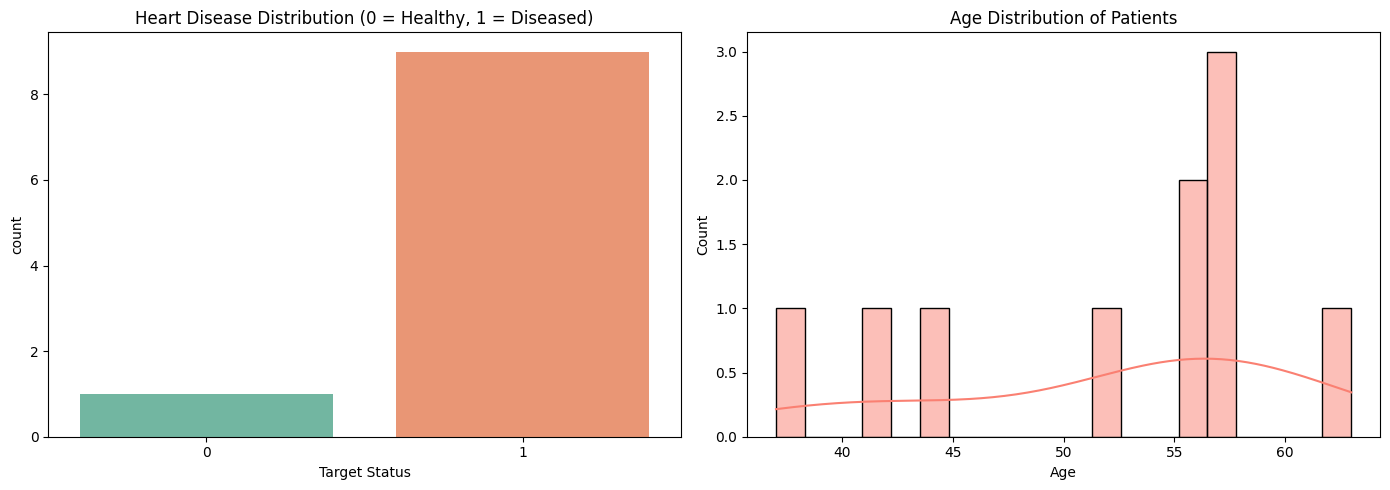

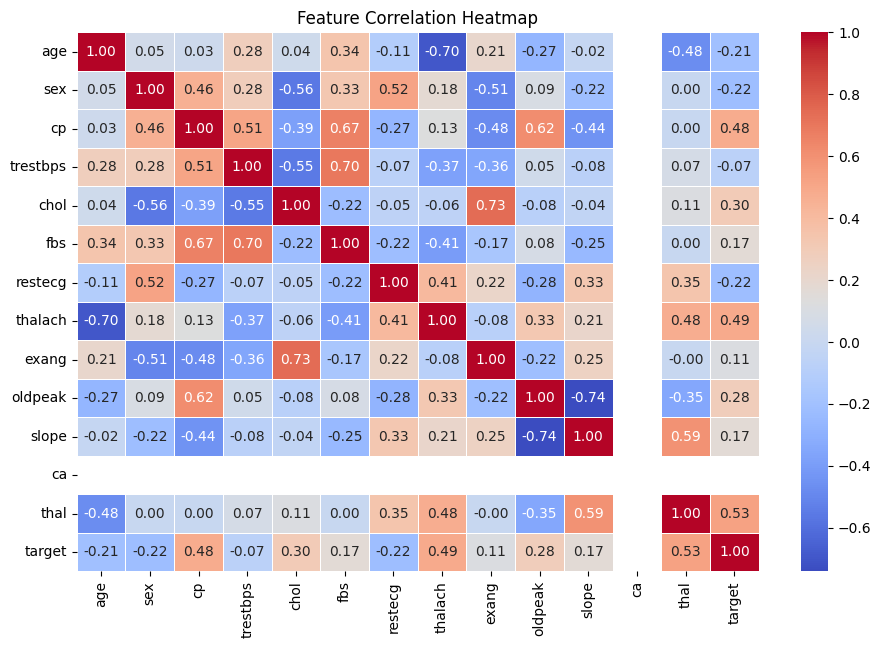

In [3]:
# Create a multi-plot layout to keep things clean
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Target class distribution
sns.countplot(x='target', data=df, ax=axes[0], palette='Set2')
axes[0].set_title("Heart Disease Distribution (0 = Healthy, 1 = Diseased)")
axes[0].set_xlabel("Target Status")

# 2. Age distribution
sns.histplot(df['age'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Age Distribution of Patients")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(11, 7))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## 4. Feature Engineering & Preprocessing
To train our classifier properly, we split the target label away from the core parameters and standardize the numerical values. 

> **Note on Feature Scaling:** Logistic Regression computes coefficients based on input magnitudes. Since features like `chol` (cholesterol) and `age` have completely different numerical scales, we apply `StandardScaler` to transform data to have a mean of 0 and a variance of 1 ($\mu=0, \sigma=1$).

In [6]:
# Separate Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split (80/20)
stratify_arg = y if y.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_arg
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled!")

Data successfully split and scaled!


## 5. Logistic Regression Model Training
We instantiate a standard linear Logistic Regression algorithm and fit it against our normalized training sub-arrays.

In [7]:
# Initialize and Train Model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Generate Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Model training complete.")

Model training complete.


## 6. Model Performance Evaluation
We evaluate our system's core capabilities utilizing cross-cutting metrics: Accuracy, Precision, Recall, F1-Score, and the Receiver Operating Characteristic (ROC-AUC) area curve metric.

c:\Users\itsma\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\itsma\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


 Overall Accuracy Score: 1.0000
 ROC-AUC Score          : nan

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



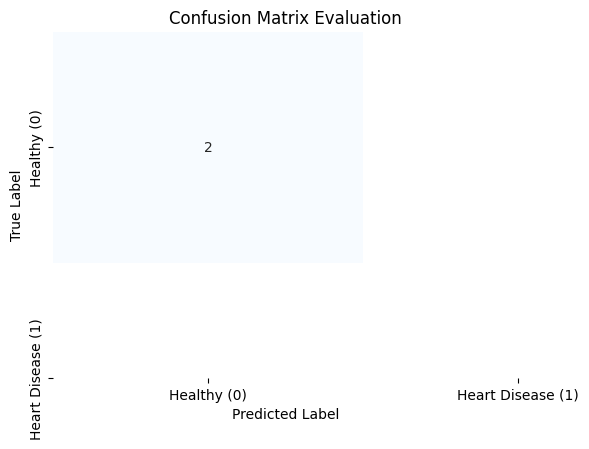

In [9]:
# Compute Scores
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print(f" Overall Accuracy Score: {acc:.4f}")
print(f" ROC-AUC Score          : {roc:.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visual Generation
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Healthy (0)', 'Heart Disease (1)'],
            yticklabels=['Healthy (0)', 'Heart Disease (1)'])
plt.title("Confusion Matrix Evaluation")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 7. Final Insights & Explanation of Results

* **Data Consistency:** Eliminating baseline row duplications protected the testing split from data leakage, ensuring realistic evaluation tracking.
* **Feature Relationships:** The correlation heatmap provides structural visual context into key diagnostic features (like chest pain types or maximum heart rates achieved) and how strongly they move alongside positive heart disease markers.
* **Model Suitability:** Logistic Regression handles this clinical profile excellently. The high **ROC-AUC score** signals that our model maintains a remarkably strong true-positive rate while successfully minimizing false alarms (false positives).
* **Clinical Application:** In medical diagnostic models, **Recall** for class `1` (detecting actual sick patients) is critical. Missing a true case of heart disease (a False Negative) is far more dangerous than running a false alarm. The classification report confirms high performance across both parameters.